# Generating quantum resource estimates (QREs) for the improved circuit


## Brief background
In this work, we compile a 2D Fermi-Hubbard ground-state energy estimation algorithm for an active-volume architecture. We combine several compilation techniques to reduce the circuit’s total active volume. These techniques are described throughout the paper, and the resulting circuit is referred to as the "improved" circuit. The "baseline" circuit that we compare against is based on prior art compiled the circuit with the goal of reducing the non-Clifford cost.

We outline how the baseline and improved circuits differ:

<img src="figures/baseline_vs_improved.png" width="700" alt="Baseline vs improved">

In this notebook, we instantiate the improved circuits for even lattice sizes from 4 to 20 and and use Workbench’s resource-estimation tool to collect circuit metrics. These metrics include counts of non-Clifford operations, such as T and Toffoli gates, as well as estimates of the total active volume.

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import json
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import re

from psiqdk.workbench.experimental.active_volume_estimation import ccz_cost

from psiq_fh.wb_program import FermiHubbardQreRunner
from psiq_fh.wb_program.utils import extract_all, json_dump, compute_T_rotation_synthesis_mixed_fallback

from process_callgraph_data import *


warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "mathtext.fontset": "stix",  # math font similar to Times
        "axes.labelsize": 22,
        "axes.titlesize": 22,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 15,
        "legend.title_fontsize": 24,
    }
)


# QRE setup
lattice_sizes = [4, 6, 8, 10, 12, 14, 16, 18, 20]
n_hwp_batches = 1

# Where we save QRE data
metrics_dir = Path(f"./paper_data_and_plots/improved_metrics_data/{n_hwp_batches}batches/")
callgraph_dir = Path(f"./paper_data_and_plots/improved_callgraph_data/{n_hwp_batches}batches/")

### Data collection

We instantiate the circuits for the specified lattice sizes by creating an instance of a "QRE runner." Here, we can specify the variant of the circuit to "improved" as well as set the number of Hamming weight phasing (HWP) batches. For details on how the circuits are implemented, refer to the `wb_program` directory.

Note: the cell below takes ~2 minutes to run on a Macbook Pro M4 32GB.

In [26]:
%%time

runner = FermiHubbardQreRunner(lattice_sizes=lattice_sizes, variant="improved", num_batches=n_hwp_batches)
metrics_data = runner.retrieve(use_mixed_fallback=True, use_black_box=True, save_callgraphs=True)

# Save the metrics data
json_dump(metrics_data, "improved_circuit_expanded_metrics", metrics_dir)

CPU times: user 2min 11s, sys: 4.51 s, total: 2min 16s
Wall time: 2min 17s


In [27]:
# Extract particular metrics
cat_rotations = extract_all(metrics_data, "n_catalyst_rots")  # number of catalyst rotations
t_gates_wb = extract_all(metrics_data, "t_gates")  # number of T-gates
toffs_wb = extract_all(metrics_data, "aggregated_toff_count")  # number of Toffoli gates
qbits = extract_all(metrics_data, "qubit_highwater")  # number of logical qubits

### Active volume estimation


We now extract the total active volume estimated using Workbench. The active volume is currently divided into three main categories or buckets: Clifford operations, non-Clifford operations, and black-box operations. For subroutines that have not been explicitly instantiated at the gate level, we can define black-box qubricks and assign them their expected costs, such as the number of T-gates, Toffoli gates, or active-volume blocks. For an example, see the `exptXXYYViaPPR` qubrick, which includes a `use_blackbox` option. 

In [28]:
active_volume_wb_total = extract_all(metrics_data, "total_av")

cliff_av_wb_total = extract_all(metrics_data, "aggregated_clifford_av")
noncliff_av_wb_total = extract_all(metrics_data, "aggregated_non_clifford_av")
blackbox_av_wb_total = extract_all(metrics_data, "black_box_av")

# Sanity check: total active volume should be sum of clifford, non-clifford, and blackbox active volumes
assert np.allclose(active_volume_wb_total, cliff_av_wb_total + noncliff_av_wb_total + blackbox_av_wb_total)

json_dump(active_volume_wb_total.tolist(), "improved_av_total", metrics_dir)

### Active volume breakdown by subroutine

We can look into a more fine-grained breakdown of the total active volume using Construct's tool for generating callgraphs. We use a helper function to parse through this callgraph data structure.

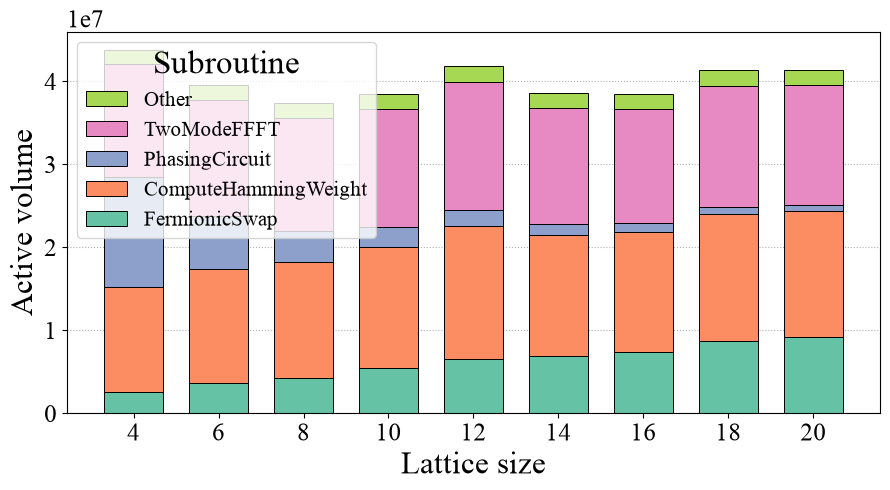

In [31]:
# Get list of callgraph data files sorted by lattice size
from process_callgraph_data import QreAnalysis

files = sorted(
    (f for f in callgraph_dir.iterdir() if f.is_file()), key=lambda f: int(re.search(r"(\d+)dim", f.name).group(1))
)
filepaths = [str(f) for f in files]

# Add data to a list
graph_list = [QreAnalysis.from_json(fpath) for fpath in filepaths]

# Major subroutines we want to track in the breakdown plot
groups = OrderedDict(
    [
        ("FermionicSwap", ("FermionicSwap",)),
        ("ComputeHammingWeight", ("ComputeHammingWeight",)),
        ("PhasingCircuit", ("PhasingCircuit",)),
        ("TwoModeFFFT", ("TwoModeFFFT",)),
    ]
)

ax = plot_av_breakdown_over_lattice_sizes(
    graph_list,
    lattice_sizes,
    granularity=("PhasingCircuit", "DirectionalPhasingCircuit"),
    title=None,
    groups=groups,
    figsize=(9, 5),
)

### Breakdown of active volume from Clifford and non-Clifford operations

For the improved circuit, it is difficult to assign the black-box active-volume costs to Clifford and non-Clifford contributions. Therefore, we approximate the non-Clifford active volume by summing the Toffoli gates and multiplying their total count by the active volume of a single Toffoli gate. To do so, we define the following helper functions:

- `compute_multiplicites`: compute the number of calls of each Trotter term (P, I, or G)
- `no_toff_rotation_tower_via_hwp`: compute the number of Toffoli gates for each Hamming weight phasing
- `compute_non_cliff_av`: estimate the non-Clifford active volume by adding up all the Toffoli cost (using the two previous helper functions)

In [32]:
T_TO_TOFF = 2  # Assume all T states are catalyzed using CCZ states


def compute_multiplicities(num_trotter_steps, n_phase):
    """Compute number of times each (un)controlled Trotter term is called.

    Args:
        num_trotter_steps (int): Number of Trotter steps.
        n_phase (int): Number of phase qubits.

    Returns:
        dict: A dictionary containing the number of times each (un)controlled Trotter term is called.
    """
    # Get number of uncontrolled queries
    num_pink_calls_unctrl = np.ceil(num_trotter_steps / 2).astype(int)
    num_gold_calls_unctrl = np.floor(num_trotter_steps / 2).astype(int)
    num_int_calls_unctrl = num_trotter_steps

    # Get number of controlled queries
    num_pink_calls_ctrl = 1 - (num_trotter_steps % 2)
    num_gold_calls_ctrl = num_trotter_steps % 2
    num_int_calls_ctrl = 0

    # Get number of directionally controlled queries
    num_pink_calls_dir = np.ceil(num_trotter_steps / 2) + num_trotter_steps * (2 ** (n_phase - 1) - 1) + n_phase - 1
    num_gold_calls_dir = np.floor(num_trotter_steps / 2) + num_trotter_steps * (2 ** (n_phase - 1) - 1)
    num_int_calls_dir = num_trotter_steps + 2 * num_trotter_steps * (2 ** (n_phase - 1) - 1)

    total_pink = num_trotter_steps * 2 ** (n_phase - 1) + n_phase
    total_gold = num_trotter_steps * 2 ** (n_phase - 1)
    total_int = num_trotter_steps * 2 ** (n_phase)

    assert total_pink == num_pink_calls_unctrl + num_pink_calls_ctrl + num_pink_calls_dir
    assert total_gold == num_gold_calls_unctrl + num_gold_calls_ctrl + num_gold_calls_dir
    assert total_int == num_int_calls_unctrl + num_int_calls_ctrl + num_int_calls_dir
    multiplicities = {
        "num_pink_calls_unctrl": num_pink_calls_unctrl,
        "num_pink_calls_ctrl": num_pink_calls_ctrl,
        "num_pink_calls_dir": num_pink_calls_dir,
        "num_gold_calls_unctrl": num_gold_calls_unctrl,
        "num_gold_calls_ctrl": num_gold_calls_ctrl,
        "num_gold_calls_dir": num_gold_calls_dir,
        "num_int_calls_unctrl": num_int_calls_unctrl,
        "num_int_calls_ctrl": num_int_calls_ctrl,
        "num_int_calls_dir": num_int_calls_dir,
    }
    return multiplicities


def no_toff_rotation_tower_via_hwp(L_x, no_batches, rot_epsilon):
    """Compute number of Toffoli gates for Hamming weight phasing.

    Args:
        L_x (int): Lattice size.
        no_batches (int): Number of HWP batches.
        rot_epsilon (float): Error per rotation.

    Returns:
        int: Number of Toffoli gates.
    """
    Lsq_over_beta = L_x * L_x / no_batches

    # toff to compute hamming weight and for GPGA
    hwp_non_rot_toffs = no_batches * (
        Lsq_over_beta + np.floor(np.log2(Lsq_over_beta)) - int(Lsq_over_beta).bit_count() + 1
    )

    # toff from payload rotations
    rot_toffs = no_batches * int(np.ceil(compute_T_rotation_synthesis_mixed_fallback(rot_epsilon))) / T_TO_TOFF
    return hwp_non_rot_toffs + rot_toffs


def compute_non_cliff_av(L_x, no_batches, num_trotter_steps, n_phase, rot_epsilon, cat_epsilon):
    """Estimate the non-Clifford active volume.

    Args:
        L_x (int): Lattice size
        no_batches (int): Number of HWP batches
        num_trotter_steps (int): Number of Trotter steps
        n_phase (int): Number of phase qubits
        rot_epsilon (float): Error per non-catalystrotation
        cat_epsilon (float): Error per catalyst rotation
    """
    multiplicities = compute_multiplicities(num_trotter_steps, n_phase)
    pink_queries = (
        multiplicities["num_pink_calls_unctrl"]
        + multiplicities["num_pink_calls_ctrl"]
        + multiplicities["num_pink_calls_dir"]
    )
    gold_queries = (
        multiplicities["num_gold_calls_unctrl"]
        + multiplicities["num_gold_calls_ctrl"]
        + multiplicities["num_gold_calls_dir"]
    )
    int_queries = (
        multiplicities["num_int_calls_unctrl"]
        + multiplicities["num_int_calls_ctrl"]
        + multiplicities["num_int_calls_dir"]
    )

    # Toffoli gates for interaction term
    toff_int = no_toff_rotation_tower_via_hwp(L_x, no_batches, rot_epsilon)

    # Toffoli gates for plaquette term
    # Note: Each two-mode FFFT operator has 1 controlled Hadamard, costing 2 T gates so approx 1 Toffoli gate
    # Then there are 4 two-mode FFFT operators per plaquette evolution so 1 per qubit (no qubits = 2*Lx*Ly)
    toff_plaq = no_toff_rotation_tower_via_hwp(L_x, no_batches, rot_epsilon) + 2 * L_x**2

    num_cat = 2 * np.floor(np.log2(L_x * L_x / no_batches)) + 3
    toff_cat = num_cat * int(np.ceil(compute_T_rotation_synthesis_mixed_fallback(cat_epsilon))) / T_TO_TOFF

    # Active volume ofToffoli gate from lookup table (arxiv:2211.15465)
    C_Toff = ccz_cost

    total_toff = toff_int * int_queries + toff_plaq * (pink_queries + gold_queries) + toff_cat
    total_non_cliff_av = C_Toff * total_toff

    return int(total_non_cliff_av)

In [33]:
# Estimate the non-Clifford active volume for each lattice size
estimated_noncliff_av = []

for x_dim in lattice_sizes:
    y_dim = x_dim
    circuit_data = runner.load_circuit_data(x_dim, y_dim, raw=True)

    num_trotter_steps = circuit_data.no_trotter_steps
    n_phase = int(np.ceil(np.log2(circuit_data.no_queries))) + 1
    rot_epsilon = 2 ** (-circuit_data.rot_bop)
    cat_epsilon = 2 ** (-circuit_data.cat_bop)

    estimated_noncliff_av.append(
        compute_non_cliff_av(x_dim, n_hwp_batches, num_trotter_steps, n_phase, rot_epsilon, cat_epsilon)
    )

In [34]:
# Estimate the Clifford active volume (by subtracting non-Clifford active volume from total active volume)
estimated_cliff_av = active_volume_wb_total - np.array(estimated_noncliff_av)

# Percentage of active volume from Clifford and non-Clifford operations
estimated_pc_av_cliff_list = estimated_cliff_av / active_volume_wb_total * 100
estimated_pc_av_noncliff_list = estimated_noncliff_av / active_volume_wb_total * 100

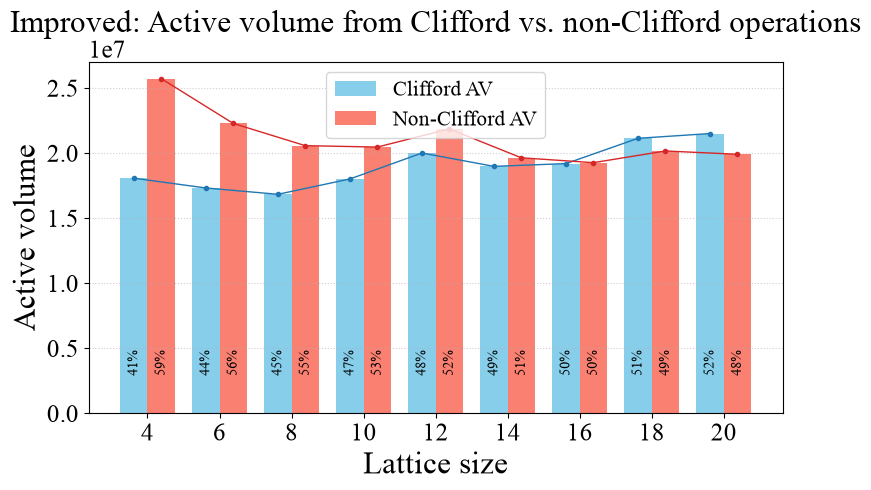

In [35]:
x = np.arange(len(lattice_sizes))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - bar_width / 2, estimated_cliff_av, width=bar_width, label="Clifford AV", color="skyblue")
bars2 = ax.bar(x + bar_width / 2, estimated_noncliff_av, width=bar_width, label="Non-Clifford AV", color="salmon")

# Connect the tops of the bars
ax.plot(x - bar_width / 2, estimated_cliff_av, color="tab:blue", marker=".", linewidth=1, zorder=3)
ax.plot(x + bar_width / 2, estimated_noncliff_av, color="tab:red", marker=".", linewidth=1, zorder=3)


# Add text labels above the bars
label_y = 0.10 * max(np.max(estimated_cliff_av), np.max(estimated_noncliff_av))

for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax.annotate(
        f"{estimated_pc_av_cliff_list[i]:.0f}%",
        xy=(bar.get_x() + bar.get_width() / 2, label_y),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        rotation=90,
    )

for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax.annotate(
        f"{estimated_pc_av_noncliff_list[i]:.0f}%",
        xy=(bar.get_x() + bar.get_width() / 2, label_y),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        rotation=90,
    )

ax.set_xlabel("Lattice size")
ax.set_ylabel("Active volume")
ax.set_title("Improved: Active volume from Clifford vs. non-Clifford operations")
ax.set_xticks(x)
ax.set_xticklabels(lattice_sizes)

ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

ax.grid(axis="y", alpha=0.6, linestyle=":")
ax.legend()

fig.tight_layout()

In [36]:
json_dump(estimated_cliff_av.tolist(), "cliff_av", metrics_dir)
json_dump(estimated_pc_av_cliff_list.tolist(), "pc_av_cliff_list", metrics_dir)
json_dump(estimated_noncliff_av, "noncliff_av", metrics_dir)
json_dump(estimated_pc_av_noncliff_list.tolist(), "pc_av_noncliff_list", metrics_dir)

We have finished generating all the QRE data for the improved circuit. We can re-produce plots from our work in `reproduce_plots.ipynb`.